In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/jofu/Refactored_DLFB")

DATA_DIR = PROJECT_ROOT / "assets"
DATA_DIR.mkdir(parents=True, exist_ok=True)

FASTA_DIR = PROJECT_ROOT / "fasta-file"
FASTA_DIR.mkdir(parents=True, exist_ok=True)

MMSEQS2_DIR = PROJECT_ROOT / "MMseqs2"
MMSEQS2_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDINGS_DIR = PROJECT_ROOT / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

os.chdir(PROJECT_ROOT)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Assets: {DATA_DIR}")
print(f"FASTA: {FASTA_DIR}")
print(f"MMSEQS2: {MMSEQS2_DIR}")
print(f"Embeddings: {EMBEDDINGS_DIR}")

Project Root: /home/jofu/Refactored_DLFB
Assets: /home/jofu/Refactored_DLFB/assets
FASTA: /home/jofu/Refactored_DLFB/fasta-file
MMSEQS2: /home/jofu/Refactored_DLFB/MMseqs2
Embeddings: /home/jofu/Refactored_DLFB/embeddings


In [2]:
!dlfb-provision --chapter proteins --destination {DATA_DIR}

Files Downloaded: 100%|███████████████████████| 22/22 [00:00<00:00, 62.15file/s]


In [2]:
%env JAX_DISABLE_JIT=True

try:
  import dlfb
except ImportError as exc:
  import site
  site.main()
  import dlfb

from dlfb.utils.display import display

env: JAX_DISABLE_JIT=True


In [3]:
#Importing pretrained ESMModel
#Option to alter the pretrained model but here want to use the same model as DLFB

from transformers import AutoTokenizer, EsmModel

model_checkpoint = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

/home/jofu/miniconda3/envs/dlfb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-05 12:46:13.187928: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777981573.217740   11810 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777981573.227720   11810 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777981573.261457   11810 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than on

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import obonet #Library which reads gene ontology files

def get_go_term_descriptions(store_path: str) -> pd.DataFrame:

  #Takes single argument store path, which is the path to a CSV file where the mapping is stored
  #Get GO term descriptions. Download OBO file if needed. Returns Pandas dataframe

  if not os.path.exists(store_path):

  #Check if the CSV file already exists, if not download process GO OBO

    url = "https://current.geneontology.org/ontology/go-basic.obo"
    graph = obonet.read_obo(url)

    # Extract GO term IDs and names from the graph nodes.
    id_to_name = {id: data.get("name") for id, data in graph.nodes(data=True)}

    #node_id and data_dict pairs for each GO term. ID=GO term ID. Data, attributes for term
    #"name" human readable. Map the term ID to the term name

    go_term_descriptions = pd.DataFrame(
      zip(id_to_name.keys(), id_to_name.values()),
      columns=["term", "description"],
    )

    #Pair each GO term ID with the name, create a dataframe, name columns

    go_term_descriptions.to_csv(store_path, index=False)

  else:
    go_term_descriptions = pd.read_csv(store_path)

  return go_term_descriptions

In [5]:
labels_path = DATA_DIR / "proteins" / "datasets" / "train_terms.tsv.zip"
labels = pd.read_csv(labels_path, sep="\t", compression="infer")

store_path = DATA_DIR / "proteins" / "datasets" / "go_term_descriptions.csv"
go_term_descriptions = get_go_term_descriptions(store_path = store_path)

labels = labels.merge(go_term_descriptions, on="term")
labels = labels[labels["aspect"] == "MFO"]

print((labels["description"].value_counts()))

description
molecular_function                                                                     78637
binding                                                                                57380
protein binding                                                                        47987
catalytic activity                                                                     25324
heterocyclic compound binding                                                          12694
                                                                                       ...  
oxidoreductase activity, acting on the CH-NH group of donors, disulfide as acceptor        1
pyrimidodiazepine synthase activity                                                        1
ecdysone 20-monooxygenase activity                                                         1
short neuropeptide F receptor activity                                                     1
ionotropic salty taste receptor activity                  

In [6]:
#Load FASTA protein sequences using SeqIO

from Bio import SeqIO

sequence_file = DATA_DIR / "proteins" / "datasets" / "train_sequences.fasta"
fasta_sequences = SeqIO.parse(open(sequence_file), "fasta")

data = []
for fasta in fasta_sequences:
  data.append(
      {
          "EntryID": fasta.id,
          "Sequence": str(fasta.seq),
          "Length": len(fasta.seq),
      }
  )
sequence_df = pd.DataFrame(data)

In [7]:
#Feature Engineering. Including mouse and rat models. Increase dataset size. High homology. Mammalian.

taxonomy_file =  DATA_DIR / "proteins" / "datasets" / "train_taxonomy.tsv.zip"
taxonomy = pd.read_csv(taxonomy_file, sep="\t", compression="infer")
sequence_df = sequence_df.merge(taxonomy, on="EntryID")
sequence_df = sequence_df[sequence_df["taxonomyID"].isin([9606, 10090, 10116])]
sequence_df = sequence_df.merge(labels, on="EntryID")

print(f"Dataset contains {sequence_df['EntryID'].nunique()} human, mouse and rat proteins with {sequence_df['term'].nunique()} molecular functions")

Dataset contains 31671 human, mouse and rat proteins with 4557 molecular functions


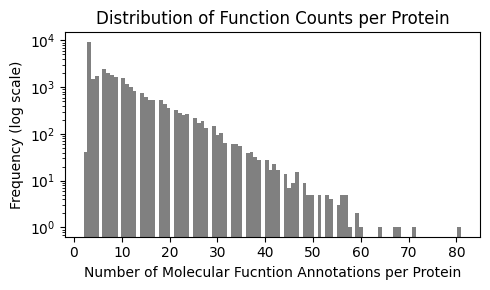

In [8]:
#Distribution of number of functions per protein

sequence_df.groupby("EntryID")["term"].nunique().plot.hist(
    bins=100, figsize=(5,3), color="grey", log=True
)
plt.xlabel("Number of Molecular Fucntion Annotations per Protein")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Function Counts per Protein")
plt.tight_layout()

In [9]:
#Remove generic functions and rare terms 

print(f"Pre-filtering size: {len(sequence_df)}")

uninteresting_functions = [
    "GO:0003674", #mol function
    "GO:0005488", #binding
    "GO:0005515", #pro binding
]

common_functions = (
    sequence_df["term"]
    .value_counts()[sequence_df["term"].value_counts() >= 50]
    .index
)

sequence_df = sequence_df[~sequence_df["term"].isin(uninteresting_functions)]
sequence_df = sequence_df[sequence_df["term"].isin(common_functions)]
sequence_df = sequence_df[sequence_df["Length"] <=500]

print(f"Post-filtering size: {len(sequence_df)}")

Pre-filtering size: 290984
Post-filtering size: 89529


In [10]:
#Clustering for more representative dataset splitting to prevent overfitting

fasta_df = sequence_df[["EntryID", "Sequence"]].drop_duplicates().set_index("EntryID")

output_fasta = FASTA_DIR / "output.fasta"

print(f"Exporting {len(fasta_df)} sequences to {output_fasta.name}...")
with open(output_fasta, "w") as f:
    for EntryID, row in fasta_df.iterrows():
        f.write(f">{EntryID}\n{row['Sequence']}\n")


!mmseqs easy-cluster "{output_fasta}" "{MMSEQS2_DIR / 'cluster_res'}" "{MMSEQS2_DIR / 'tmp'}" --min-seq-id 0.4 -c 0.8

print(f"Clustering complete. Results saved in: {MMSEQS2_DIR}")

Exporting 12476 sequences to output.fasta...
easy-cluster /home/jofu/Refactored_DLFB/fasta-file/output.fasta /home/jofu/Refactored_DLFB/MMseqs2/cluster_res /home/jofu/Refactored_DLFB/MMseqs2/tmp --min-seq-id 0.4 -c 0.8 

MMseqs Version:                     	18.8cc5c
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.8
Coverage mode                       	0
Compositional bias                  	1
Compositional bias scale           

In [11]:
sequence_df = (
sequence_df[["EntryID", "Sequence", "Length", "term"]]
.assign(value=1)
.pivot(
index=["EntryID", "Sequence", "Length"], columns="term", values="value"
)
.fillna(0)
.astype(int)
.reset_index()
)

In [12]:
#Taking the clustering data
cluster_file = MMSEQS2_DIR / "cluster_res_cluster.tsv"
clusters_df = pd.read_csv(cluster_file, sep="\t", names=["ClusterID", "EntryID"])

#1 row per protein ID
unique_clusters = (clusters_df[["EntryID", "ClusterID"]].drop_duplicates(subset="EntryID", keep="first"))

pre_splitting_df = sequence_df.merge(unique_clusters, on="EntryID", how="left")

#Moving ClusterID to the second column 
col = pre_splitting_df.pop("ClusterID")
pre_splitting_df.insert(1, col.name, col)

print(f"Merged cluster and sequence df...")
print(f"Number of unique clusters: {pre_splitting_df['ClusterID'].nunique()}")

Merged cluster and sequence df...
Number of unique clusters: 5564


In [13]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

#Create a Test set
test_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

#Indicies for training, valid and test datasets. Keeping clusters together to prevent data leakage
training_validation_index, test_index = next(test_splitter.split(pre_splitting_df, groups=pre_splitting_df["ClusterID"]))

#Dataframes for (training and validation) and test data sets
df_training_validation = pre_splitting_df.iloc[training_validation_index].reset_index(drop=True)
test_data = pre_splitting_df.iloc[test_index].reset_index(drop=True)

#Trying to balance GO terms across the folds. Imperfect with low GO terms but have to do it.
sgkf = StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True)

for fold, (train_sequence_ids, valid_sequence_ids) in enumerate(sgkf.split(df_training_validation, df_training_validation["ClusterID"], groups=df_training_validation["ClusterID"])):
  training_data = df_training_validation.iloc[train_sequence_ids]
  validation_data = df_training_validation.iloc[valid_sequence_ids]

#Checking size of the dataset splits
sequence_splits = {
    "train":training_data,
    "valid":validation_data,
    "test":test_data
 }

for split, df in sequence_splits.items():
  print(f"{split} dataset has {len(df)} entries")

/home/jofu/miniconda3/envs/dlfb/lib/python3.10/site-packages/sklearn/model_selection/_split.py:950: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


train dataset has 7881 entries
valid dataset has 1963 entries
test dataset has 2632 entries


In [14]:
model.to("cuda")

import src

from tqdm.auto import tqdm
from src.models_utils import store_sequence_embeddings, load_sequence_embeddings

model_checkpoint = "facebook/esm2_t30_150M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#Extracting and storing mean embedding for each protein sequence

for split, df in sequence_splits.items():
  store_sequence_embeddings(
      sequence_df = df,
      store_prefix = f"mean_embeddings_{split}",
      tokenizer = tokenizer,
      model = model,
      directory = EMBEDDINGS_DIR
  )

NameError: name 'store_sequence_embeddings' is not defined

In [36]:
#Datasets for the model 

train_df = load_sequence_embeddings("mean_embeddings_train", model_checkpoint=model_checkpoint, directory=EMBEDDINGS_DIR)
valid_df = load_sequence_embeddings("mean_embeddings_valid", model_checkpoint=model_checkpoint, directory=EMBEDDINGS_DIR)
test_df = load_sequence_embeddings("mean_embeddings_test", model_checkpoint=model_checkpoint, directory=EMBEDDINGS_DIR)

In [19]:
#Build tensorflow compatible dataset
#640 dimensional embedding vector and a target of a 303 dimensional binary vector

from dlfb.proteins.dataset import convert_to_tfds

train_ds = convert_to_tfds(train_df, is_training = True)

batch_size = 32
batch = next(iter(train_ds.batch(batch_size)))

emb_shape = batch["embedding"].shape
tar_shape = batch["target"].shape

print(f"Embedding Shape: {emb_shape} (Expected: (32, 640))")

Embedding Shape: (32, 640) (Expected: (32, 640))


In [24]:
import src
from src.models_utils import build_dataset
import tensorflow as tf

dataset_splits = build_dataset(EMBEDDINGS_DIR, model_checkpoint=model_checkpoint)

In [25]:
import jax
import flax.linen as nn
from flax.training.train_state import TrainState
from src.models_utils import ProteinMLP

targets = list(train_df.columns[train_df.columns.str.contains("GO:")])
mlp = ProteinMLP(num_targets=len(targets))

In [26]:
@jax.jit #Jax just in time compilation (speeds it all up)
def train_step(state, batch):
  """Run a single training step and update model parametres"""

  def calculate_loss(params):
    """Compute sigmoid cross-entropy loss from logits""" #(unnormalised numerical scores/sigmoid curve loss)
    logits = state.apply_fn({"params":params}, x=batch["embedding"])
    loss = optax.sigmoid_binary_cross_entropy(logits, batch["target"]).mean()
    return loss

  grad_fn = jax.value_and_grad(calculate_loss, has_aux=False)
  loss, grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state, loss

In [31]:
#Compute accuracy

import sklearn
from src.models_utils import compute_metrics
from dlfb.proteins.train import train

In [29]:
def eval_step(state, batch) -> dict[str,float]:
  """Run evaluation step. Return mean metrics over the targets"""
  logits=state.apply_fn({"params":state.params}, x=batch["embedding"])
  loss=optax.sigmoid_binary_cross_entropy(logits, batch["target"]).mean()
  target_metrics=calculate_per_target_metrics(logits, batch["target"])
  metrics={"loss":loss.item(), **pd.DataFrame(target_metrics).mean(axis=0).to_dict(),}
  return metrics

def calculate_per_target_metrics(logits, targets):
  """Compute metrics for each target in a multi-label batch"""
  probs=jax.nn.sigmoid(logits)
  target_metrics=[]
  for target, prob in zip(targets, probs):
    target_metrics.append(compute_metrics(target, prob))
  return target_metrics

In [33]:
import flax.training.train_state as train_state
import optax
from dlfb.utils.restore import restorable

# 1. Re-initialise the object so it uses the new code
mlp = ProteinMLP(num_targets=len(targets), dim=512)

# 2. Manual Init
variables = mlp.init(jax.random.PRNGKey(0), batch["embedding"], train=False)
params = variables['params']

# 3. Create State
manual_state = train_state.TrainState.create(
    apply_fn=mlp.apply,
    params=params,
    tx=optax.adam(0.001)
)

# 4. Final Training Call
state, metrics = restorable(train)(
    state=manual_state,
    dataset_splits=dataset_splits,
    batch_size=32,
    num_steps=600,
    eval_every=30,
    store_path="proteins/models/mlp_600",
)

Step 600: 100%|██████████| 600/600 [19:09<00:00,  1.92s/it]  


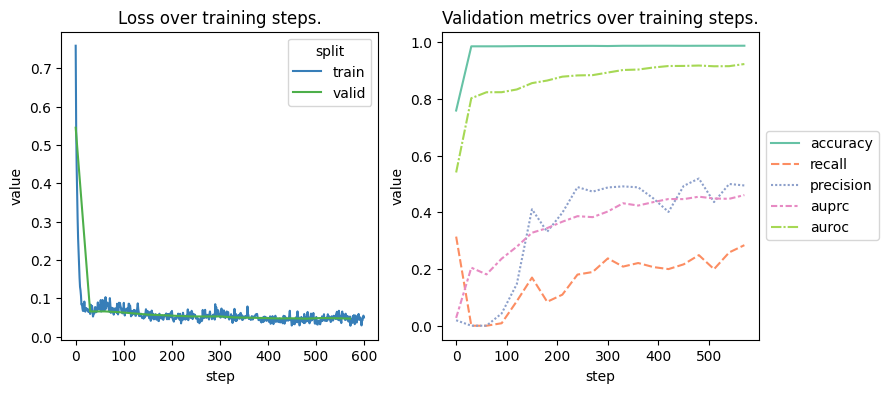

In [34]:
#Evaluation of training dynamics and performance on validation set

import matplotlib.pyplot as plt
import seaborn as sns

from dlfb.utils.metric_plots import DEFAULT_SPLIT_COLORS

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9,4))

#Training loss curve
learning_data = pd.concat(
    pd.DataFrame(metrics[split]).melt("step").assign(split=split)
    for split in ["train", "valid"]
)

sns.lineplot(
    ax=ax[0],
    x="step",
    y="value",
    hue="split",
    data=learning_data[learning_data["variable"] == "loss"],
    palette = DEFAULT_SPLIT_COLORS,
)
ax[0].set_title("Loss over training steps.")

#Validation metrics curve
sns.lineplot(
    ax=ax[1],
    x="step",
    y="value",
    hue="variable",
    style="variable",
    data=learning_data[learning_data["variable"] != "loss"],
    palette="Set2",
)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax[1].set_title("Validation metrics over training steps.");

In [37]:
#Batch size of one prevent dropping remainder

valid_probs = []
for valid_batch in dataset_splits["valid"].batch(1).as_numpy_iterator():
  logits = state.apply_fn({"params":state.params}, x=valid_batch["embedding"])
  valid_probs.extend(jax.nn.sigmoid(logits))

valid_true_df = valid_df[["EntryID"] + targets].set_index("EntryID")
valid_prob_df = pd.DataFrame(
    np.stack(valid_probs), columns=targets, index=valid_true_df.index
)

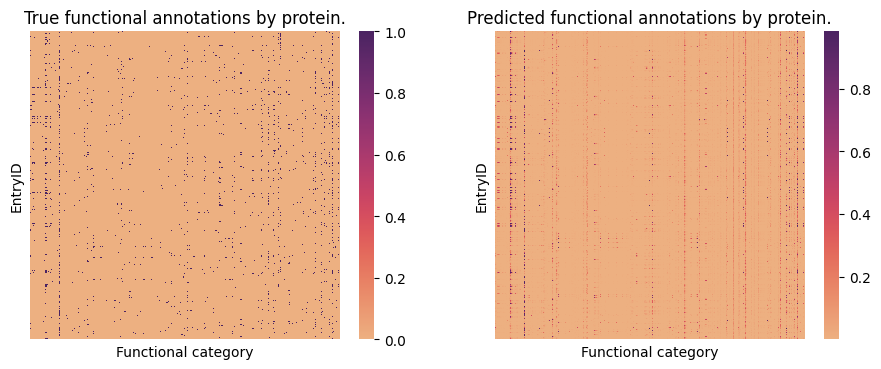

In [38]:
#Heatmap of predicted protein function
#Left ground truth. Right is predicted probabilities

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11,4))

sns.heatmap(
    ax=ax[0],
    data=valid_true_df,
    yticklabels=False,
    xticklabels=False,
    cmap="flare",
)
ax[0].set_title("True functional annotations by protein.")
ax[0].set_xlabel("Functional category")

sns.heatmap(
    ax=ax[1],
    data=valid_prob_df,
    yticklabels=False,
    xticklabels=False,
    cmap="flare"
)

ax[1].set_title("Predicted functional annotations by protein.")
ax[1].set_xlabel("Functional category");

In [41]:
#Quantify

metrics_by_function ={}
for function in targets:
  metrics_by_function[function] = compute_metrics(
      valid_true_df[function].values, valid_prob_df[function].values
  )

overview_valid = (
    pd.DataFrame(metrics_by_function)
    .T.merge(go_term_descriptions, left_index=True, right_on="term")
    .set_index("term")
    .sort_values("auprc", ascending=False)
)

overview_valid = overview_valid.merge(
    pd.DataFrame(train_df[targets].sum(), columns=["train_n"]),
    left_index=True,
    right_index=True,
)

Text(0, 0.5, 'Validation auPRC')

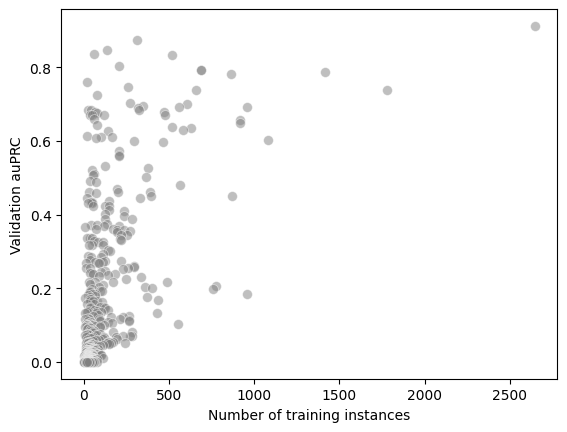

In [42]:
#Scatterplot visualisation

fig = sns.scatterplot(
    x="train_n", y="auprc", data=overview_valid, alpha=0.5, s=50, color="grey"
)
fig.set_xlabel("Number of training instances")
fig.set_ylabel("Validation auPRC")

In [43]:
def make_coin_flip_predictions(
    valid_true_df: pd.DataFrame, targets: list[str]
) -> pd.DataFrame:
  predictions = np.random.choice([0.0, 1.0], size=valid_true_df.shape)
  return pd.DataFrame(predictions, columns=targets, index=valid_true_df.index)

def make_proportional_predictions(
   valid_true_df: pd.DataFrame, train_df: pd.DataFrame, targets: list[str]
) -> pd.DataFrame:

  percent_1_train = dict(train_df[targets].mean())
  proportional_preds = []
  for target_column in targets:
    prob_1 = percent_1_train[target_column]
    prob_0 = 1 - prob_1
    proportional_preds.append(
        np.random.choice([0.0, 1.0], size=len(valid_true_df), p=[prob_0, prob_1])
    )
  return pd.DataFrame(
      np.stack(proportional_preds).T, columns=targets, index=valid_true_df.index
  )

In [44]:
prediction_methods = {
    "coin_flip_baseline": make_coin_flip_predictions(valid_true_df, targets),
    "proportional_guess_baseline": make_proportional_predictions(
        valid_true_df, train_df, targets
    ),
    "model": valid_prob_df,
}

In [ ]:
metrics_by_method ={}
for method, preds_df in prediction_methods.items():
  metrics_by_method[method] = pd.DataFrame(
      [
          compute_metrics(valid_true_df.iloc[i], preds_df.iloc[i])
          for i in range (len(valid_true_df))
      ]
  ).mean()

           coin_flip_baseline  proportional_guess_baseline     model
accuracy             0.500756                     0.972294  0.987693
recall               0.501818                     0.073406  0.238551
precision            0.014748                     0.069093  0.496273
auprc                0.015778                     0.027750  0.472154
auroc                0.501303                     0.529599  0.928565


In [46]:
auprc_by_function = {}

for method, preds_df in prediction_methods.items():
  metrics_by_function = {}

  for function in targets:
    metrics_by_function[function] = compute_metrics(
        valid_true_df[function], preds_df[function]
    )

  auprc_by_function[method] = (
      pd.DataFrame(metrics_by_function)
      .T.merge(go_term_descriptions, left_index=True, right_on="term")
      .set_index("term")
      .sort_values("auprc", ascending=False)
  )["auprc"].to_dict()

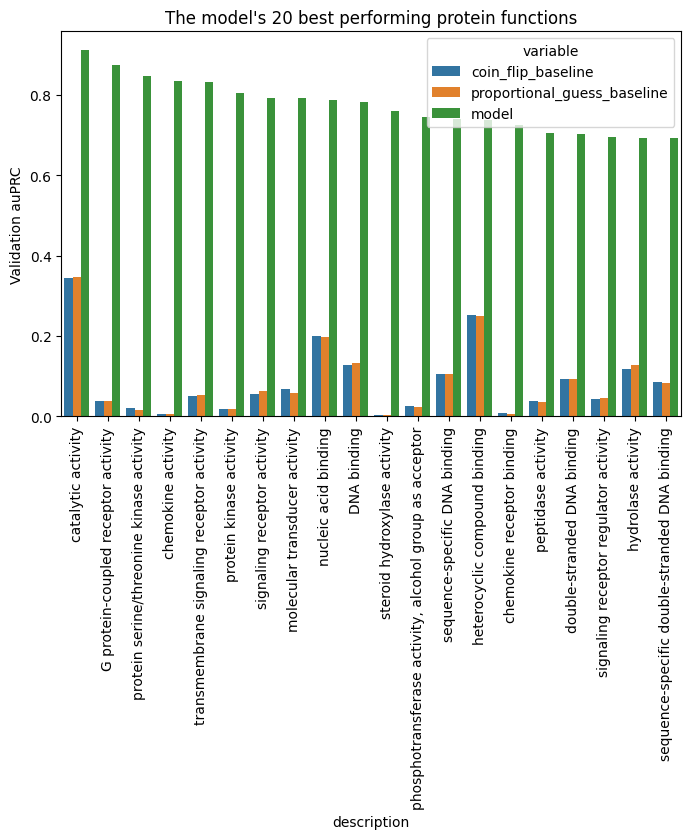

In [47]:
best_performing = (
pd.DataFrame(auprc_by_function)
.merge(go_term_descriptions, left_index=True, right_on="term")
.set_index("term")
.sort_values("model", ascending=False)
.head(20)
.melt("description")
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
x="description",
y="value",
hue="variable",
data=best_performing,
)
ax.set_title("The model's 20 best performing protein functions")
ax.set_ylabel("Validation auPRC")
plt.xticks(rotation=90);

In [49]:
eval_metrics = []

for split in ["valid", "test"]:
    split_metrics = []

    for eval_batch in dataset_splits[split].batch(32).as_numpy_iterator():
        split_metrics.append(eval_step(state, eval_batch))

    eval_metrics.append({"split": split, **pd.DataFrame(split_metrics).mean(axis=0).to_dict()})
    print(pd.DataFrame(eval_metrics))

   split      loss  accuracy    recall  precision     auprc     auroc
0  valid  0.045695  0.987719  0.238473    0.49535  0.471522  0.928473
   split      loss  accuracy    recall  precision     auprc     auroc
0  valid  0.045695  0.987719  0.238473   0.495350  0.471522  0.928473
1   test  0.049019  0.986966  0.221798   0.493831  0.455864  0.923144
